# Process Tree Discovery

Discover process trees from an event log using the inductive miner, visualize them, convert to BPMN, and analyze structural regions (subtrees) as candidates for subprocess extraction.

In [1]:
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from collections import Counter

## Load Event Log
Read a simple event log (AB_Example.xes) for process discovery.

In [2]:
LOG_PATH = "../data/examples/running-example.xes" 
event_log = log_converter.apply(pm4py.read_xes(LOG_PATH) )

c:\Users\safaya\Documents\GitHub\process-fragment-miner\.venv\Lib\site-packages\pm4py\utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/6 [00:00<?, ?it/s]

## Discover Process Tree
Use the inductive miner to discover a process tree from the event log.

In [3]:
process_tree = pm4py.discover_process_tree_inductive(
    event_log
)

print(process_tree)

->( 'register request', *( ->( +( 'check ticket', X( 'examine thoroughly', 'examine casually' ) ), 'decide' ), 'reinitiate request' ), X( 'reject request', 'pay compensation' ) )


## Save Process Tree as PTML
Serialize the discovered process tree to a PTML file for reuse.

In [4]:
import os
os.makedirs("../data/examples/models", exist_ok=True)
ptml_name = os.path.splitext(os.path.basename(LOG_PATH))[0] + ".ptml"
OUTPUT_PATH = f"../examples/models/{ptml_name}"
pm4py.write_ptml(process_tree, OUTPUT_PATH)
print(f"Process tree saved to {OUTPUT_PATH}")

FileNotFoundError: [Errno 2] No such file or directory: '../examples/models/running-example.ptml'

## Visualize Process Tree
Render the process tree as an image.

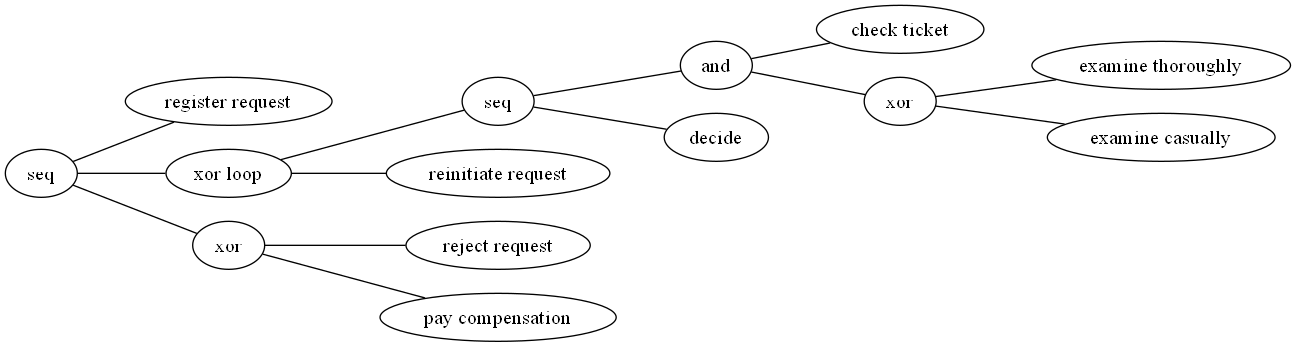

In [ ]:
pm4py.view_process_tree(
    process_tree
)

## Convert to BPMN
Transform the process tree into a BPMN model for a different visual perspective.

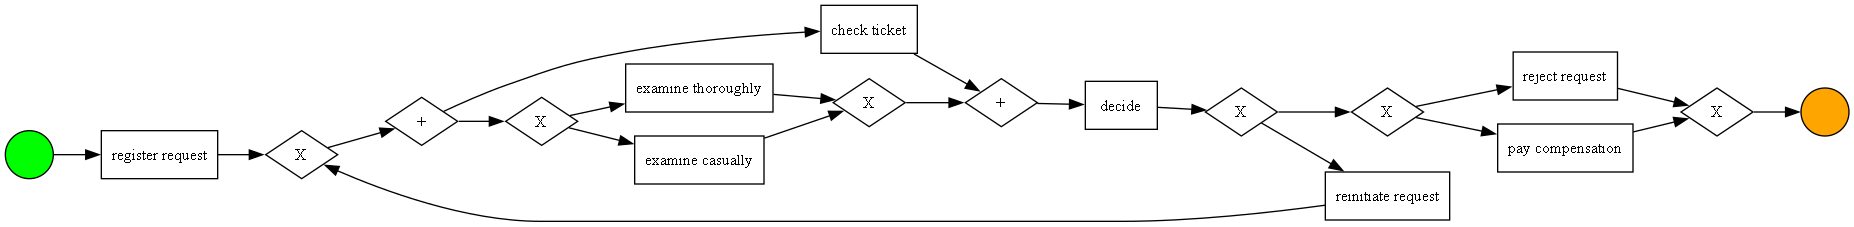

In [ ]:
bpmn_model = pm4py.convert_to_bpmn(
    process_tree
)

pm4py.view_bpmn(
    bpmn_model
)

## Discover BPMN Model

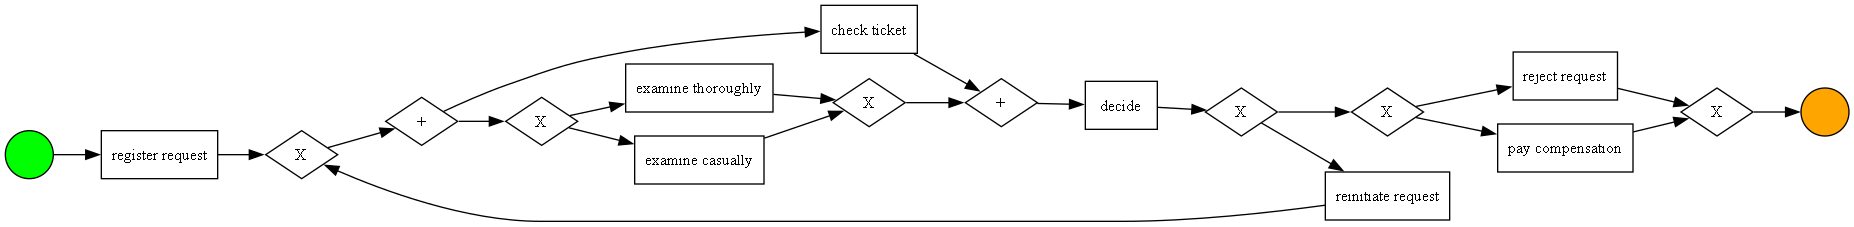

In [ ]:
process_model = pm4py.discover_bpmn_inductive(
    event_log
)

pm4py.view_bpmn(
    process_model
)